In [48]:
path_ldp_af = '/carnegie/nobackup/scratch/xwu/grenet/merged_frequency/merged_hapFIRE_allele_frequency_LDpruned.txt'

In [49]:
library("LEA")
library("vcfR")
library("dplyr")

In [50]:
## all of these is for allele freq 

#final_gen <- read.csv('final_gen.csv', stringsAsFactors = FALSE)$sample_name
#allele_freq <- read.table(path_ldp_af, sep = "\t", header = TRUE, check.names = FALSE)
#allele_freq <- allele_freq[, final_gen]  # Select only columns listed in 'final_gen'

## the format should be individuals by loci , so indivudlas == rows and loci == columns so im gonna trasnpose it 
## and then convert it into a matrix 
#allele_freq = as.matrix(t(allele_freq))

#k <-  as.integer(readLines('LEA_analyses/num_components.txt'))

## get the environment
#env <- as.matrix(read.csv('LEA_analyses/environment_lea.csv', header = TRUE,colClasses = "numeric"))
#env <- as.numeric(env)  # Convert to numeric

## delete the site
#env <- env[, colnames(env) != "site"]

In [51]:
## this part is to start with the genotype matrix

In [52]:
#path_metadata = '/home/tbellagio/grene/data/'
env_data_ecotypes <- read.csv('/home/tbellagio/grene/data/worldclim_ecotypesdata.csv')
# Select only the required columns
env_data_ecotypes <- select(env_data_ecotypes, ecotypeid, bio1)

ld_prunned_vcf_file = '/carnegie/nobackup/scratch/xwu/grenet/hapFIRE_updatedVCF/greneNet_final_v1.1_LDpruned.recode.vcf'
vcf_file_path = '/carnegie/nobackup/scratch/xwu/grenet/hapFIRE_updatedVCF/greneNet_final_v1.1.recode.vcf'

vcf_full <- read.vcfR(ld_prunned_vcf_file)
geno_full <- vcf_full@gt[,-1] 

##take the sample names from teh vcf file to cehck the order 
sample_names <- colnames(vcf_full@gt)[-1]
sample_names <- as.character(sample_names)

## order the environemtnal file based on the order in the genotype file 
env_data_ecotypes$ecotypeid <- as.character(env_data_ecotypes$ecotypeid)

env_data_ecotypes_ordered <- env_data_ecotypes[match(sample_names, env_data_ecotypes$ecotypeid), ]

###################### DELETE THIS IN THE FUTURE ######################
env_data_ecotypes_ordered[is.na(env_data_ecotypes_ordered)] <- 0
###################### DELETE THIS IN THE FUTURE ######################

## now that is ordered extract only the enviornmental variable 
env_variable = env_data_ecotypes_ordered$bio1

env_variable = matrix(env_variable)

Scanning file to determine attributes.
File attributes:
  meta lines: 27
  header_line: 28
  variant count: 13985
  column count: 240
Meta line 27 read in.
All meta lines processed.
gt matrix initialized.
Character matrix gt created.
  Character matrix gt rows: 13985
  Character matrix gt cols: 240
  skip: 0
  nrows: 13985
  row_num: 0
Processed variant: 13985
All variants processed


In [61]:
C = matrix(runif(6), ncol=2, nrow=3)


In [62]:
C

0.42589591,0.7617348
0.07331522,0.3781132
0.19196804,0.4611888


In [63]:
write.env(env_variable,"env_variable.env")

[1] "env_variable.env"

In [60]:
read.env(env_variable)

ERROR: Error in read.env(env_variable): 'input.file' argument has to be of type character.


In [53]:
dim(env_variable)

[1] 231   1

In [54]:
dim(geno_full)

[1] 13985   231

In [55]:
position_full <- getPOS(vcf_full)

In [56]:
G_full <- matrix(NA, nrow = nrow(geno_full), ncol = ncol(geno_full))

G_full[geno_full %in% c("0/0", "0|0")] <- 0
G_full[geno_full  %in% c("0/1", "1/0", "1|0", "0|1")] <- 1
G_full[geno_full %in% c("1/1", "1|1")] <- 2

In [57]:
## so the function from lffm write.lfmm takes the genotypes matrix an converts it to the lfmm format, 
## that u can then use to run the pc 
lfmmfile <- paste0('LEA_analyses/', "ldp_genotypes.lfmm")
write.lfmm(t(G_full), lfmmfile)

[1] "LEA_analyses/ldp_genotypes.lfmm"

In [67]:
G_full

0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
0,2,2,0,0,0,2,0,0,0,⋯,0,0,0,2,0,0,0,0,0,2
0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,2,2,0,0,0,0
0,0,0,2,2,0,2,0,0,0,⋯,2,0,0,0,2,2,0,2,0,0
2,0,2,2,2,0,0,0,0,0,⋯,2,0,0,0,2,2,0,2,0,2
0,2,0,0,0,0,0,0,0,0,⋯,0,0,0,0,2,0,0,0,0,0
0,2,0,0,0,0,0,0,0,0,⋯,0,0,0,0,2,2,0,0,0,0
0,2,2,0,0,2,2,0,0,0,⋯,0,0,0,2,0,0,0,0,0,0
2,0,0,2,2,2,2,2,2,2,⋯,0,2,2,0,0,0,2,2,2,2
0,0,2,0,0,0,2,2,0,0,⋯,0,0,2,2,0,0,0,0,2,0
0,2,2,0,0,2,0,2,2,0,⋯,2,0,2,0,0,0,0,0,2,0


In [58]:
lfmmfile

[1] "LEA_analyses/ldp_genotypes.lfmm"

In [83]:

pc = pca(lfmmfile, 231, scale = TRUE)

[1] "LEA_analyses/ldp_genotypes.lfmm"

[1] "******************************"
[1] " Principal Component Analysis "
[1] "******************************"
summary of the options:

        -n (number of individuals)          231
        -L (number of loci)                 13985
        -K (number of principal components) 231
        -x (genotype file)                  /carnegie/nobackup/scratch/tbellagio/gea_grene-net/LEA_analyses/ldp_genotypes.lfmm
        -a (eigenvalue file)                /carnegie/nobackup/scratch/tbellagio/gea_grene-net/LEA_analyses/ldp_genotypes.pca/ldp_genotypes.eigenvalues
        -e (eigenvector file)               /carnegie/nobackup/scratch/tbellagio/gea_grene-net/LEA_analyses/ldp_genotypes.pca/ldp_genotypes.eigenvectors
        -d (standard deviation file)        /carnegie/nobackup/scratch/tbellagio/gea_grene-net/LEA_analyses/ldp_genotypes.pca/ldp_genotypes.sdev
        -p (projection file)                /carnegie/nobackup/scratch/tbellagio/gea_grene-net/LEA_analyses/ldp_genotypes.pca/ldp_genotypes.p

In [84]:
tw = tracy.widom(pc)

[1] "*******************"
[1] " Tracy-Widom tests "
[1] "*******************"
summary of the options:

        -n (number of eigenvalues)          231
        -i (input file)                     /carnegie/nobackup/scratch/tbellagio/gea_grene-net/LEA_analyses/ldp_genotypes.pca/ldp_genotypes.eigenvalues
        -o (output file)                    /carnegie/nobackup/scratch/tbellagio/gea_grene-net/LEA_analyses/ldp_genotypes.pca/ldp_genotypes.tracywidom


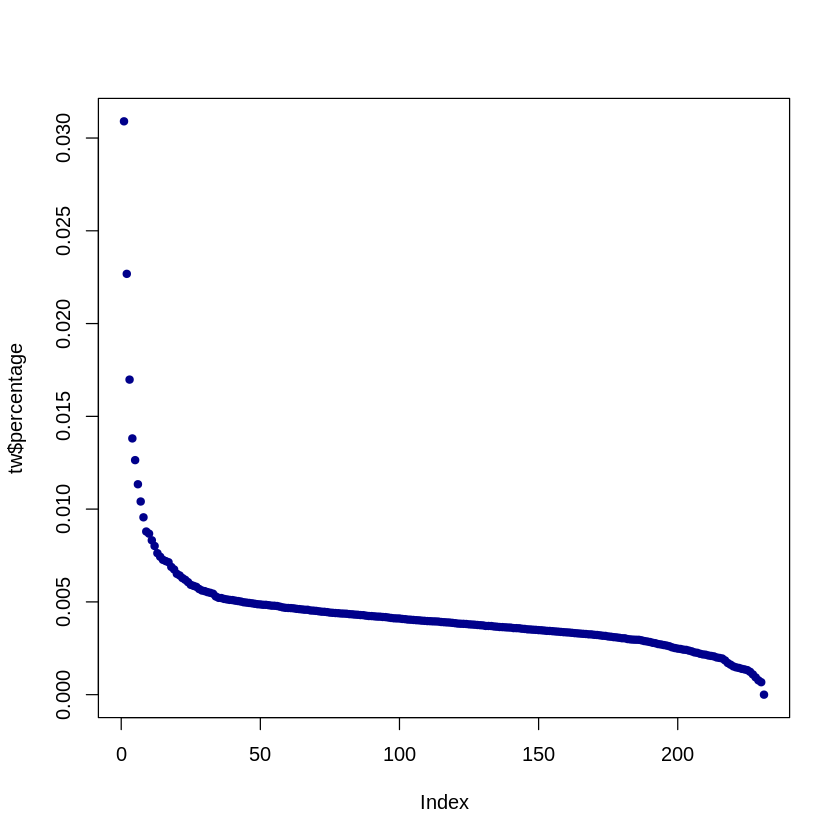

In [85]:
# plot the percentage of variance explained by each component 
plot(tw$percentage, pch = 19, col = "darkblue", cex = .8)

In [114]:
## Fit an LFMM, i.e., compute B, U, V estimates
mod2 <- lfmm2(input = t(G_full), 
              env = env_variable, 
              K = 30)

pv <- lfmm2.test(object = mod2,
                 input = t(G_full),
                 env = env_variable)

In [ ]:
## import the environemtns from the experiment 

In [10]:
experimental_sites_climate <- read.csv('/home/tbellagio/grene/data/worldclim_sitesdata.csv')

# Select only the required columns
experimental_sites_climate <- select(experimental_sites_climate, site, bio1)

experimental_sites_bio1 = experimental_sites_climate$bio1

experimental_sites_bio1 = matrix(experimental_sites_bio1)

new_env = matrix(experimental_sites_bio1[1,] , nrow = nrow(env_variable) , ncol = 1)


In [11]:
any(is.na(env_variable))
any(is.na(new_env))
any(is.na(t(G_full)))

[1] FALSE

[1] FALSE

[1] FALSE

In [12]:
print(dim(random_matrix_uniform)) 

ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'print': object 'random_matrix_uniform' not found


In [29]:
random_matrix_uniform <- matrix(runif(231), nrow = 231, ncol = 1)
random_matrix_uniform
# View the first few entries of the matrix
head(random_matrix_uniform)

0.42365845
0.37563916
0.99854169
0.04388195
0.61621202
0.34106475


In [46]:
random_matrix_uniform = random_matrix_uniform * 10

In [28]:
g.gap <- genetic.gap(
                    input = G_full,
                    env = env_variable,
                    pred.env = env_variable,
                    K = 30)

ERROR: Error in cov(B): supply both 'x' and 'y' or a matrix-like 'x'


In [77]:
pop <- matrix(1:231, nrow = 231, ncol = 1)

In [79]:
G_full = t(G_full)

In [80]:
print(dim(G_full))  # Should be 13985 x 231 for 'input'
print(dim(env_variable))   # Should be 231 x 1 for 'env'
print(dim(new_env))        # Should be 231 x 1 for 'pred.env'
print(dim(pop))    

[1]   231 13985
[1] 231   1
[1] 231   1
[1] 231   1


In [64]:
write.env(new_env,"env_variable_new.env")

[1] "env_variable_new.env"

In [ ]:
new_env

In [66]:
lfmmfile

[1] "LEA_analyses/ldp_genotypes.lfmm"

In [74]:
G_full[G_full == 2] <- 1

In [81]:
g.offset <- genetic.offset(input = G_full,
                        env = env_variable,
                        pred.env = new_env, 
                        pop.labels = pop,
                        pca = 30, 
                       )


ERROR: Error in genetic.offset(input = G_full, env = env_variable, pred.env = new_env, : Population samples in pop.labels must have more than one individual.


In [42]:
g.offset

ERROR: Error in eval(expr, envir, enclos): object 'g.offset' not found


In [21]:
nrow(G_full)

[1] 13985

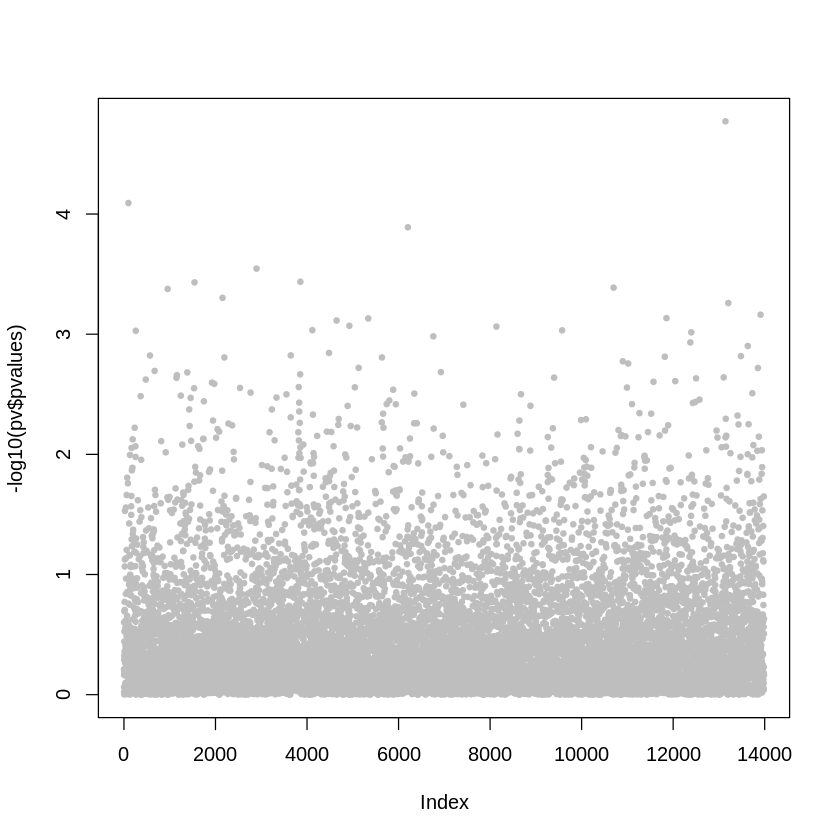

In [68]:
plot(-log10(pv$pvalues), col = "grey", cex = .6, pch = 19)
abline(h = -log10(0.1/nrow(G_full)), lty = 2, col = "orange")

In [9]:
## for allele freq
## Fit an LFMM, i.e., compute B, U, V estimates
#mod2 <- lfmm2(input = allele_freq, 
#              env = env, 
#              K = k)

In [24]:
## for allele freq 
#pv <- lfmm2.test(object = mod2,
#                 input = allele_freq,
#                 env = env)

In [29]:
# P-values for 't2m_celcius'
pvalues_t2m <- pv$pvalues["t2m_celcius", ]
# P-values for 'tp_mm'
pvalues_tp <- pv$pvalues["tp_mm", ]
# P-values for 'ssrd'
pvalues_ssrd <- pv$pvalues["ssrd", ]

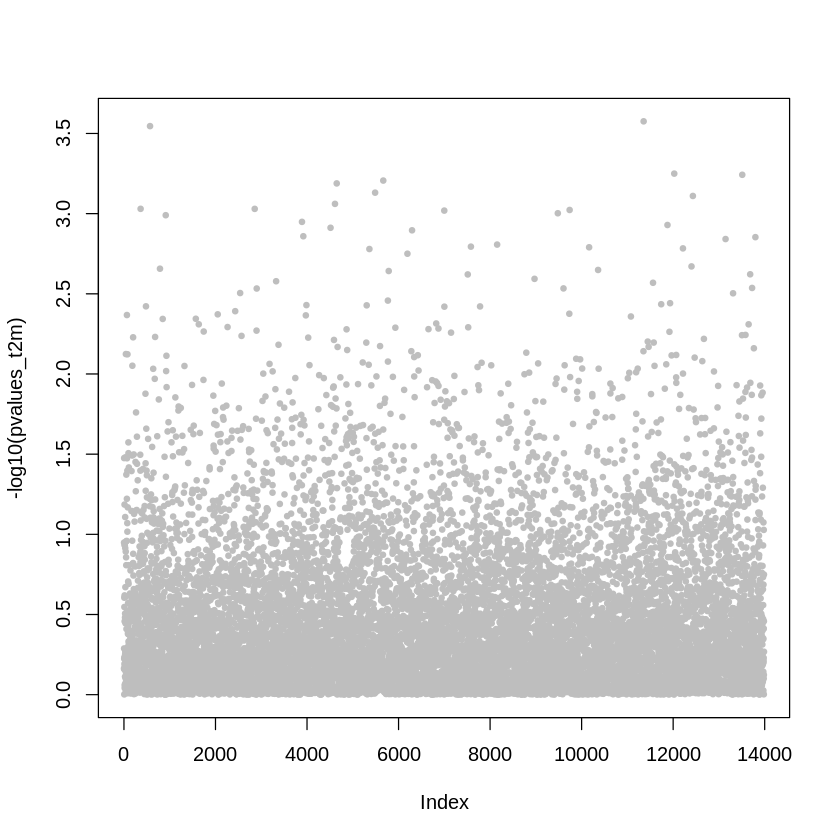

In [32]:
plot(-log10(pvalues_t2m), col = "grey", cex = .6, pch = 19)
abline(h = -log10(0.1/ncol(allele_freq)), lty = 2, col = "orange")

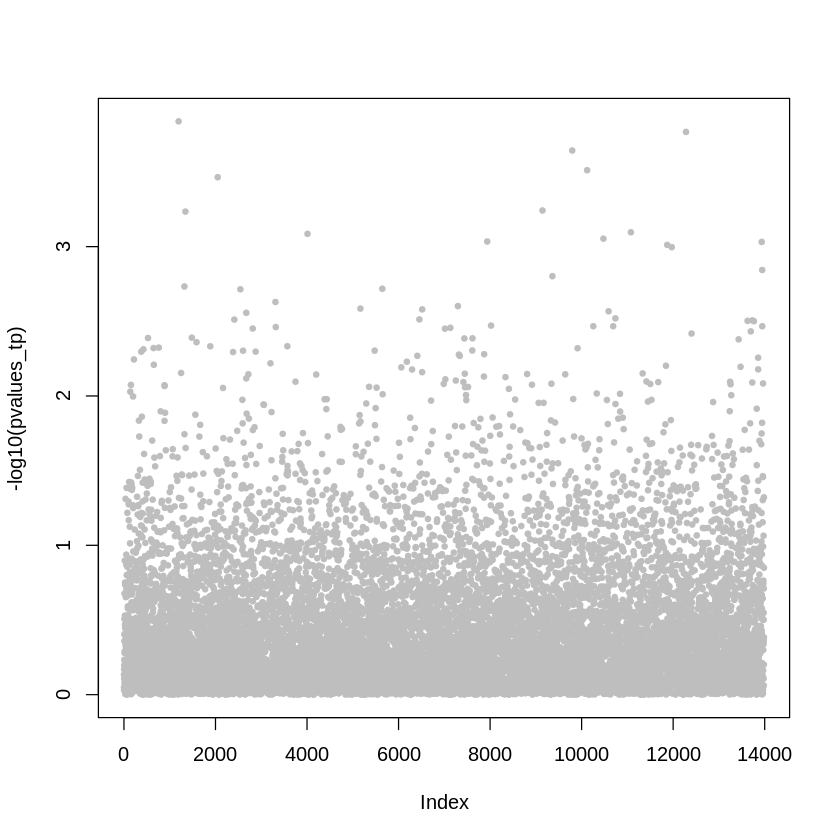

In [33]:
plot(-log10(pvalues_tp), col = "grey", cex = .6, pch = 19)
abline(h = -log10(0.1/ncol(allele_freq)), lty = 2, col = "orange")

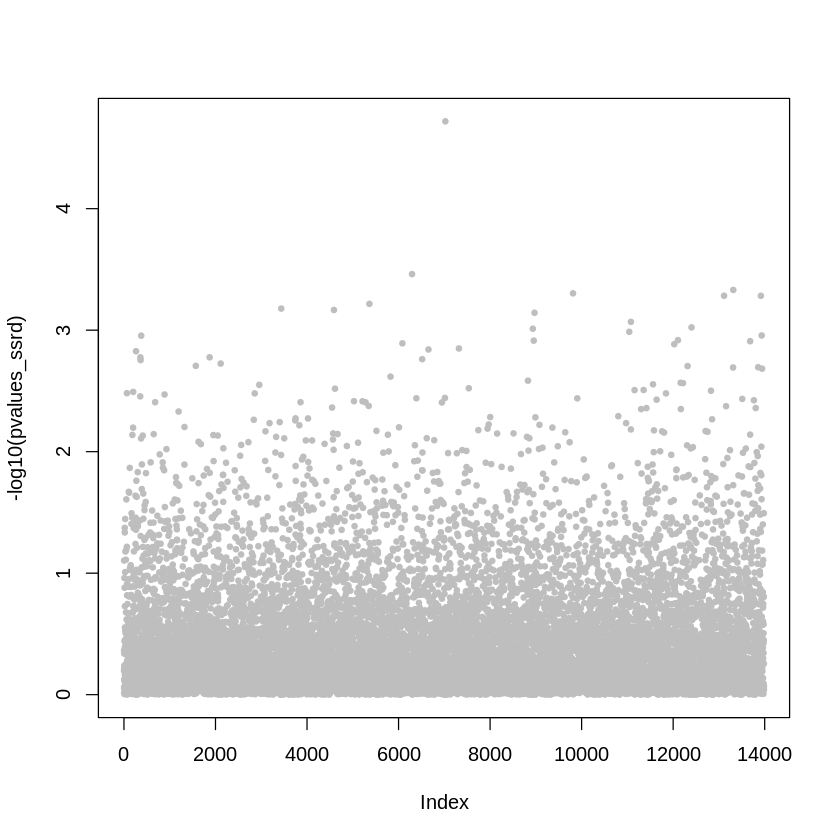

In [34]:
plot(-log10(pvalues_ssrd), col = "grey", cex = .6, pch = 19)
abline(h = -log10(0.1/ncol(allele_freq)), lty = 2, col = "orange")

In [35]:
pv <- lfmm2.test(object = mod2,
                 input = allele_freq,
                 env = env,
                full=TRUE)

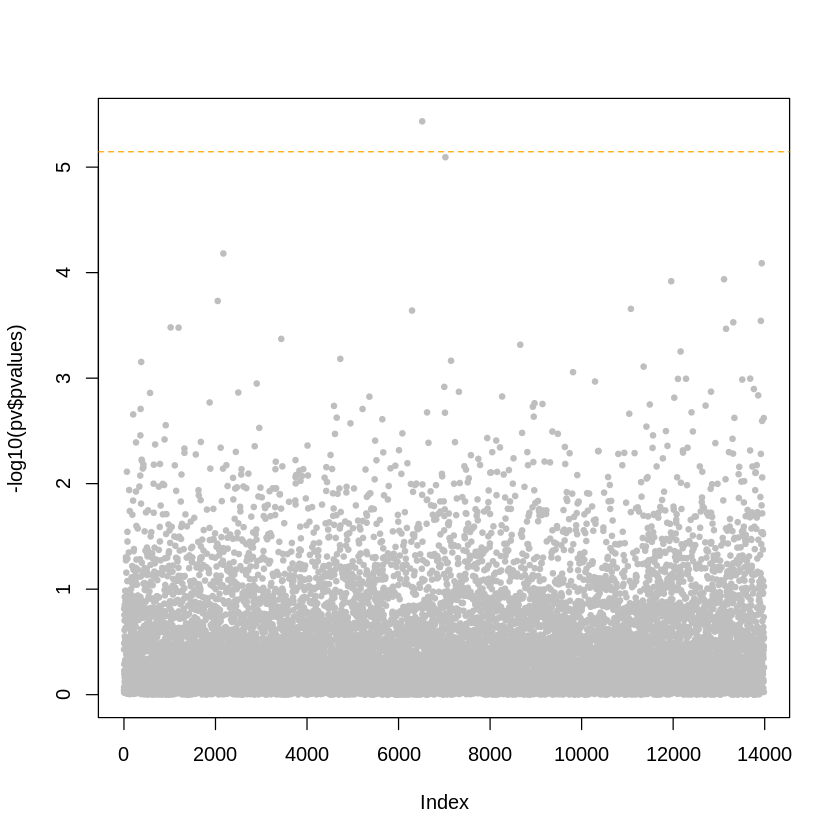

In [36]:
plot(-log10(pv$pvalues), col = "grey", cex = .6, pch = 19)
abline(h = -log10(0.1/ncol(allele_freq)), lty = 2, col = "orange")

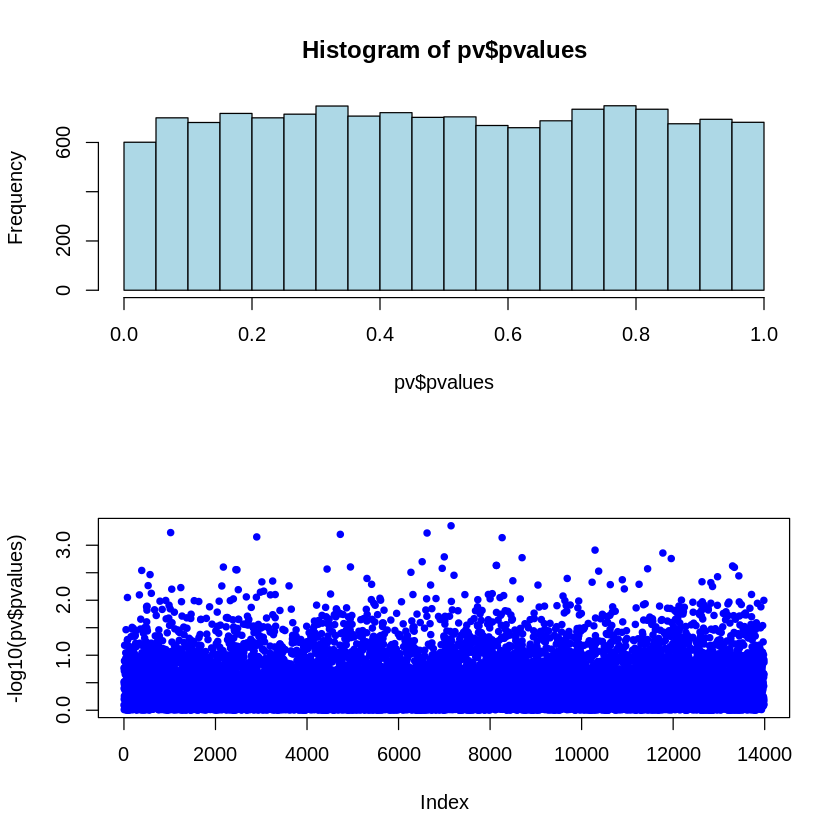

In [12]:
# GEA significance test
par(mfrow = c(2,1))
hist(pv$pvalues, col = "lightblue")
plot(-log10(pv$pvalues), pch = 19, col = "blue", cex = .7)

In [ ]:
Then the offfset can be easily calcualted with 
https://github.com/ModelValidationProgram/MVP-offsets/blob/8d650793d8fcdfa36135fa663d6ddd33ceb5832b/01_src/MVP_complex_sims_process_lfmm.R#L2

In [ ]:

## using 5 because that is what I estimated based on the screeplot 
mod.lfmm <- lfmm_ridge(Y = Y_t, 
                     X = X, 
                     K = num_components)

## Perform association testing using the fitted model:
pv <- lfmm_test(Y = Y_t, 
              X = X, 
              lfmm = mod.lfmm, 
              calibrate = "gif")

pvalues <- pv$calibrated.pvalue

In [ ]:

# Computing genetic offset statistics for 2 populations, defined from latent factor 1
pop <-  1 + (U[,1] > 0)

In [ ]:
new.env = 2*X + 10, 
object = mod2,

In [16]:
pop <- matrix(1:231, nrow = 231, ncol = 1)


In [11]:

g.offset <- genetic.offset( input = Y, 
                           env = X, 
                           pop.labels = pop)


ERROR: Error in genetic.offset(input = Y, env = X, pop.labels = pop): argument "pred.env" is missing, with no default


In [ ]:
round(g.offset, digit = 3) 

In [14]:
getwd()

[1] "/carnegie/nobackup/scratch/tbellagio/gea_grene-net/LEA_analyses"

In [12]:
# creation of a directory for LEA analyses
dir.create("LEA_analyses")
# set the created directory as the working directory
setwd("LEA_analyses")

In [15]:
library(LEA)
# Creation of a genotype matrix data file: "genotypes.lfmm"
# The data include 400 SNPs for 50 individuals.
data("tutorial")
# Write genotypes in the lfmm format
write.lfmm(tutorial.R, "genotypes.lfmm")
# Write genotypes in the geno format
write.geno(tutorial.R, "genotypes.geno")
# creation of an environment gradient file: gradient.env.
# The .env file contains a single ecological variable

[1] "genotypes.lfmm"

[1] "genotypes.geno"

In [16]:
# for each individual.
write.env(tutorial.C, "gradients.env")

[1] "gradients.env"

In [ ]:
https://github.com/ModelValidationProgram/MVP-NonClinalAF/blob/c43df8c373b188de208feb742ac5ec21279a4a2f/src/c-AnalyzeSimOutput.R#L676

In [ ]:
lfmm2()

In [ ]:
mod_temp <- lfmm2(input = t(G_full_subset), env = subset_indPhen_df$temp_opt, K = K)

In [ ]:

library(lfmm)

geno_file = snakemake@input[['gen']]
env_file = snakemake@input[['env']]
num_components_file = snakemake@input[['num_components']]

pvalues_file = snakemake@output[['p_values_lfmm']]
qqplot_file = snakemake@output[['qq_plot']]

# Read the num_components
num_components <- readLines(num_components_file, warn = FALSE) 
num_components <- as.integer(num_components[1])

# Read the geno and env tables 
Y <- as.matrix(read.csv(geno_file, sep = ',', header = FALSE))
X <- as.matrix(read.csv(env_file, sep = '', header = FALSE))

# Check the number of columns in Y
if (ncol(Y) <= 3) {
  # Create the p-values file with 0 inside
  write.csv(0, file = pvalues_file, row.names = FALSE)
  
  # Create the empty PNG file
  file.create(qqplot_file)
} else {
  # Proceed with LFMM analysis
  
  ## Transpose Y because of the format needed for lfmm 
  Y_t <- t(Y)
  
  ## Fit an LFMM, i.e., compute B, U, V estimates
  ## using 5 because that is what I estimated based on the screeplot 
  mod.lfmm <- lfmm_ridge(Y = Y_t, 
                         X = X, 
                         K = num_components)
  
  ## Perform association testing using the fitted model:
  pv <- lfmm_test(Y = Y_t, 
                  X = X, 
                  lfmm = mod.lfmm, 
                  calibrate = "gif")
  
  pvalues <- pv$calibrated.pvalue
  
  ## Write p-values
  write.csv(pvalues, file = pvalues_file, row.names = FALSE)
  
  # Set the file path and name for the PNG file
  png_file <- qqplot_file
  
  # Open the PNG file device
  png(filename = png_file)
  
  # Generate the plot
  qqplot(rexp(length(pvalues), rate = log(10)),
         -log10(pvalues), xlab = "Expected quantile",
         pch = 19, cex = 0.4)
  abline(0, 1)
  
  # Close the device and save the file
  dev.off()
}

In [ ]:
### PCA ####
lfmmfile <- paste0(path, seed, "_genotypes.lfmm")
write.lfmm(t(G_full_subset), lfmmfile)

pc = pca(lfmmfile, 30, scale = TRUE)
saveRDS(pc,paste0(path, seed, "_pca.RDS"))
print("calculated pca")
subset_indPhen_df$PC1 <- pc$projections[,1]
subset_indPhen_df$PC2 <- pc$projections[,2]
subset_indPhen_df$PC3 <- pc$projections[,3]
tw = tracy.widom(pc)
plot(tw$percentage)
a <- tw$percentage[1:20]
b <- tw$percentage[2:21]
K1 <- max(which(a > b*1.5))
K2 <- max(which(a > b*1.4))
K3 <- max(which(a > b*1.3)) # a little safety net if the first criteria doesn't work
if (!is.infinite(K1)){K=K1}
if (is.infinite(K1)){K=K3}
if (is.infinite(K)){print("Error K is not definite"); break}
print(c("K=",K))
print(c("K1=", K1, "K2=", K2, "K3=", K3))
propvarpc <- pc$sdev[1:15]/sum(pc$sdev)

pdf(paste0(path,seed,"_pdf_3pca.pdf"), width=9, height=8)

propvarpc <- pc$sdev[1:15]/sum(pc$sdev)
plot(propvarpc, bty="l", ylab="Prop Var of PC axis", main=paste0(plotmain, "; K=", K), cex.main=0.5)

ggplot(subset_indPhen_df) + ggtheme + geom_point(aes(x=PC1, y=PC2,size=sal_opt), color="grey20") + 
geom_point(aes(x=PC1, y=PC2, color=temp_opt), size=2.5) +  
scale_colour_gradient2(high=rgb(1,0.4,0.2), low="cornflowerblue", mid=rgb(0.8,0.8,0.7), name="Temp") + 
labs(size="Env2") + ggtitle(paste0(plotmain, "; K=", K)) + 
xlab(paste0("PC1 (", round(propvarpc[1]*100,1),"%)")) +
ylab(paste0("PC2 (", round(propvarpc[2]*100,1),"%)"))


ggplot(subset_indPhen_df) + ggtheme + geom_point(aes(x=PC1, y=PC3,size=sal_opt), color="grey20") + geom_point(aes(x=PC1, y=PC3, color=temp_opt), size=2.5) + scale_colour_gradient2(high=rgb(1,0.4,0.2), low="cornflowerblue", mid=rgb(0.8,0.8,0.7), name="Temp") + labs(size="Env2") + ggtitle(paste0(plotmain,  "; K=", K)) + 
xlab(paste0("PC1 (", round(propvarpc[1]*100,1),"%)")) +
ylab(paste0("PC3 (", round(propvarpc[3]*100,1),"%)"))


dev.off()

In [146]:
print(dim(G_full_int))  # Should be 13985 x 231 for 'input'
print(dim(env_variable))   # Should be 231 x 1 for 'env'
print(dim(new_env))  

[1]   231 13985
[1] 231   1
[1] 231   1


In [147]:
data("offset_example")
Y <- offset_example$geno
X <- offset_example$env
X.pred <- offset_example$env.pred
#PCA of the genotype data suggests k = 2 factors


In [148]:
print(dim(Y))  # Should be 13985 x 231 for 'input'
print(dim(X))   # Should be 231 x 1 for 'env'
print(dim(X.pred)) 

[1] 200 510
[1] 200   4
[1] 200   4


In [151]:
X.pred

0.521,0.776,0.058,1.258
0.831,0.455,1.023,1.310
0.764,0.051,1.377,0.878
0.282,0.596,-0.178,0.838
0.846,-0.154,1.774,0.784
0.192,0.700,-0.469,0.833
0.633,0.241,0.904,0.904
0.260,0.080,0.393,0.354
0.761,0.301,1.074,1.097
0.412,0.549,0.123,0.938
0.848,0.299,1.239,1.190


In [130]:
#Y # A matrix: 200 × 510 of type int

#X # A matrix: 200 × 4 of type dbl

# X.pred # A matrix: 200 × 4 of type dbl


In [131]:
g.gap <- genetic.gap(input = Y,
env = X,
pred.env = X.pred,
K = 2)

In [61]:
g.gap

0.8724828,0.41209882,0.0501248,-0.25775164
-0.4161316,0.87964378,0.2265171,0.04184907
-0.2482799,0.03346041,-0.4253824,-0.86964779
-0.0629718,-0.23512079,0.8747727,-0.41895760


In [56]:
data("offset_example")
Y <- offset_example$geno
X <- offset_example$env
X.pred <- offset_example$env.pred

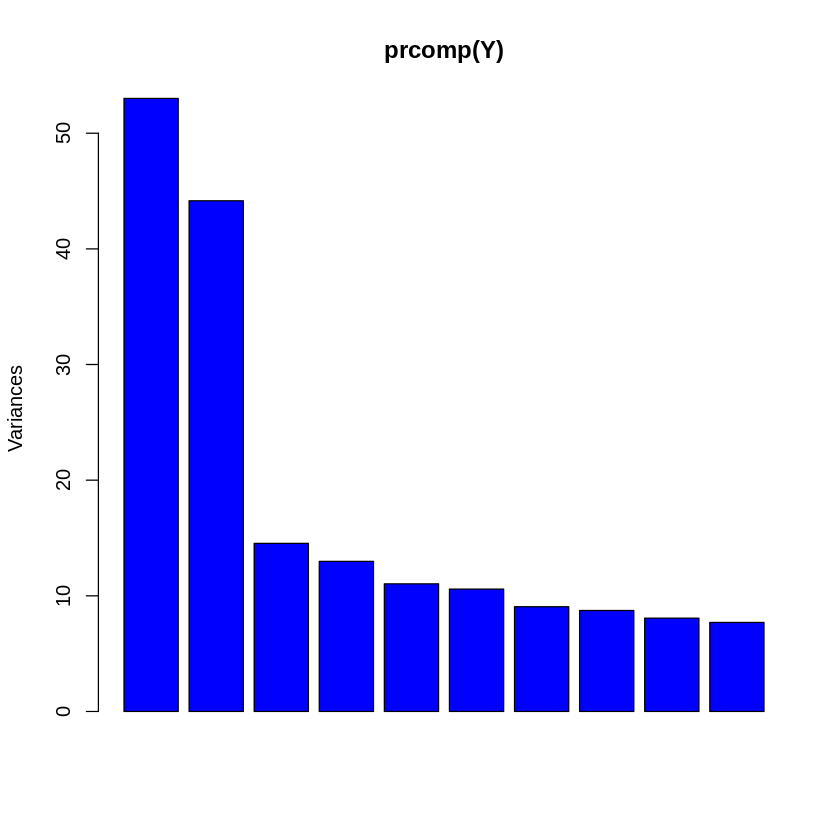

In [23]:

#PCA of the genotype data suggests k = 2 factors
plot(prcomp(Y), col = "blue")
## genetic gap


In [20]:
library("LEA")
### Example of offset prediction using lfmm2 ###

# Simulation with 100 target loci, with effect sizes ranging between -10 an 10 
# n = 100 individuals and L = 1000 loci

env <- as.matrix(rnorm(100)) # environmental variable
B <- rep(0, 1000) 
target <- sample(1:1000, 100) # target loci
B[target] <- runif(100, -10, +10) # effect sizes

# Creating hidden factors and loadings

U <- t(tcrossprod(as.matrix(c(-1.25,0.5,1.25)), env)) + matrix(rnorm(300), ncol = 3)
V <- matrix(rnorm(3000), ncol = 3)

# Simulating a binarized matrix containing haploid genotypes 
# Simulation performed with a generative LFMM

Y <- tcrossprod(as.matrix(env), B) + tcrossprod(U, V) + matrix(rnorm(100000, sd = .5), nrow = 100)
Y <- matrix(as.numeric(Y > 0), ncol = 1000)

######################################
# Fitting an LFMM with K = 3 factors #
######################################


In [21]:
pop <-  1 + (U[,1] > 0)

In [22]:
pop

[1] 2 2 2 2 2 1 1 2 1 1 1 2 1 2 1 2 2 2 2 1 1 1 2 2 2 1 2 1 1 2 1 2 1 1 1 1 1
 [38] 1 1 1 2 2 2 1 2 2 1 2 2 1 1 2 1 1 2 1 1 2 1 1 2 1 1 1 2 1 1 1 1 2 2 2 2 2
 [75] 2 1 1 2 2 2 2 2 2 2 1 1 2 1 1 1 2 2 1 1 2 1 2 1 1 1

In [23]:
dim(pop)

NULL

In [24]:
dim(env)

[1] 100   1

In [25]:
dim(Y)

[1]  100 1000

In [27]:
new.env = 2*env + 10

In [28]:
dim(new.env)

[1] 100   1

In [ ]:

mod2 <- lfmm2(input = Y, env = X, K = 3)

# Computing genetic offset statistics for 2 populations, defined from latent factor 1


g.offset <- genetic.offset(object = mod2, 
                           input = Y, 
                           env = env, 
                           new.env = new.env, 
                           pop.labels = pop)
print(round(g.offset, digit = 3))

#rm(list = ls())

In [68]:
library("LEA")
### Example of offset prediction using lfmm2 ###

# Simulation with 100 target loci
# Effect sizes ranging between -10 an 10 
# n = 100 individuals and L = 1000 loci

X <- as.matrix(rnorm(100)) # environmental variable
B <- rep(0, 1000) 
target <- sample(1:1000, 100) # target loci
B[target] <- runif(100, -10, +10) # effect sizes

# Creating hidden factors and their loadings

U <- t(tcrossprod(as.matrix(c(-1.25,0.5,1.25)), X)) + 
   matrix(rnorm(300), ncol = 3)

V <-  matrix(rnorm(3000), ncol = 3)

# Simulating a binarized matrix of haploid genotypes 
# Simulation performed with a generative LFMM

Y <- tcrossprod(as.matrix(X), B) + tcrossprod(U, V) + 
   matrix(rnorm(100000, sd = .5), nrow = 100)

Y <-  matrix(as.numeric(Y > 0), ncol = 1000)

In [71]:
Y[Y == 1] <- 2

In [72]:


######################################
# Fitting an LFMM with K = 98 factors#
######################################


# Computing genetic offset statistics for 2 populations 
# defined from PCA

pop <- 1 + (prcomp(Y, scale = TRUE)$x[,1] > 0)

g.offset <- genetic.offset(input = Y, 
                        env = X, pred.env = 2*X + 10, 
                        pop.labels = pop)
round(g.offset, digit = 3) 



# Computing genetic offset statistics for 2 populations, 
# defined from ANOVA and  truly targeted loci

g.offset <- genetic.offset(input = Y, 
                        env = X, pred.env = 2*X + 10, 
                        pop.labels = pop,
                        pca = FALSE, 
                        candidate.loci = target)

print(g.offset) 


Random phase and duplication of samples: 
                  Creating two haploid genomes from each individual genome. 


Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(object, ...):
“essentially perfect fit: summary may be unreliable”
Warning message in summary.lm(

ERROR: Error in x$coeff[1:(K + d + 1), 1]: subscript out of bounds


In [15]:
matrix(pop)

1
1
1
1
1
1
2
2
2
2
2
